# Machine Fault Prediction
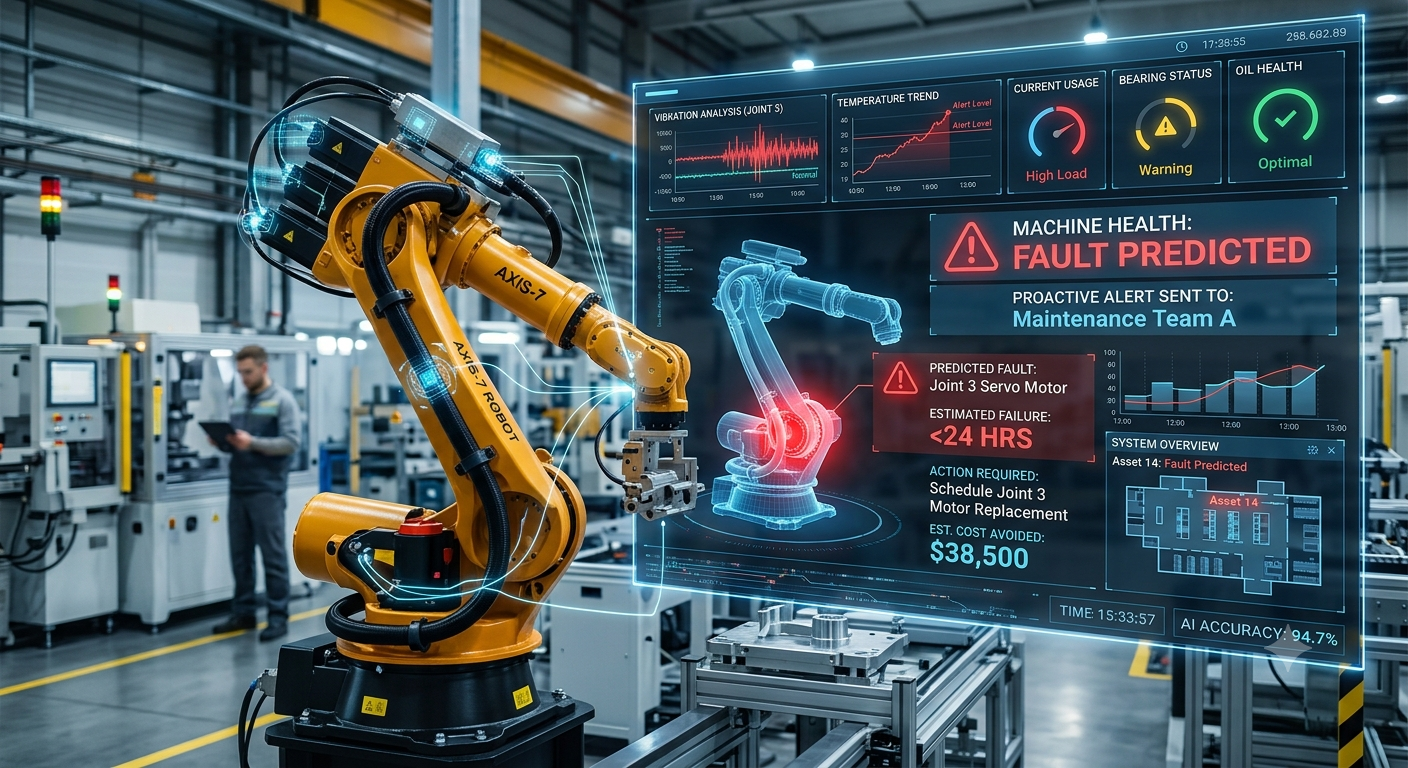

## Business Context

In industrial environments, machines operate continuously under different conditions such as temperature, vibration, pressure, RPM, electrical current, voltage, load, and operating hours. Unexpected machine faults can lead to production downtime, maintenance costs, and operational disruptions.

The goal of this project is to use machine operating and maintenance data to identify patterns associated with machine faults and support proactive maintenance decisions.

## Business Objective

Develop a machine learning classification model that can predict whether a machine is **Normal or Faulty** based on its operating conditions, maintenance information, and failure history.

The objective is to help businesses:

* Detect potential machine faults early.
* Reduce unexpected machine downtime.
* Support preventive maintenance planning.
* Improve machine reliability and operational efficiency.
* Reduce maintenance-related costs.


# Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score , recall_score , f1_score , confusion_matrix , roc_auc_score , ConfusionMatrixDisplay

# Load Dataset

In [ ]:
df = pd.read_csv('machine_fault_detection.csv')

# Data Overview

In [ ]:
df.head(5)

,Machine_ID,Temperature_C,Vibration_mm_s,Pressure_bar,RPM,Current_A,Voltage_V,Operating_Hours,Load_Percentage,Maintenance_Count,Last_Maintenance_Days,Failure_History,Machine_Status
0,M00001,75.96,3.28,89.88,1513,7.41,417.75,5633,94.46,1,86,No,Normal
1,M00002,68.34,3.95,88.97,2114,10.83,413.20,7116,67.91,4,101,Yes,Normal
2,M00003,77.77,3.42,71.89,2418,8.04,441.65,4917,83.79,3,245,No,Normal
3,M00004,88.28,4.70,93.11,2897,8.71,457.92,7417,100.00,5,121,No,Fault
4,M00005,67.19,6.65,64.14,3466,10.15,434.23,6641,30.73,4,48,No,Normal


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Machine_ID             10000 non-null  object 
 1   Temperature_C          10000 non-null  float64
 2   Vibration_mm_s         10000 non-null  float64
 3   Pressure_bar           10000 non-null  float64
 4   RPM                    10000 non-null  int64  
 5   Current_A              10000 non-null  float64
 6   Voltage_V              10000 non-null  float64
 7   Operating_Hours        10000 non-null  int64  
 8   Load_Percentage        10000 non-null  float64
 9   Maintenance_Count      10000 non-null  int64  
 10  Last_Maintenance_Days  10000 non-null  int64  
 11  Failure_History        10000 non-null  object 
 12  Machine_Status         10000 non-null  object 
dtypes: float64(6), int64(4), object(3)
memory usage: 1015.8+ KB


In [ ]:
df.shape

(10000, 13)

In [ ]:
df.describe(include='all')

,Machine_ID,Temperature_C,Vibration_mm_s,Pressure_bar,RPM,Current_A,Voltage_V,Operating_Hours,Load_Percentage,Maintenance_Count,Last_Maintenance_Days,Failure_History,Machine_Status
count,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000,10000
unique,10000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2
top,M09984,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,Normal
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7204,7000
mean,NaN,69.980744,4.534042,84.825810,2794.974400,8.516616,414.973391,5801.921300,67.595754,3.013700,105.412800,NaN,NaN
std,NaN,12.018775,1.776347,13.835193,648.266905,2.295144,27.999453,2662.368086,17.614569,1.733555,61.254376,NaN,NaN
min,NaN,35.000000,0.500000,45.000000,1000.000000,2.000000,330.000000,376.000000,15.000000,0.000000,2.000000,NaN,NaN
25%,NaN,61.930000,3.310000,75.197500,2348.750000,6.970000,396.047500,3777.000000,55.587500,2.000000,60.000000,NaN,NaN
50%,NaN,69.970000,4.530000,84.920000,2793.000000,8.520000,415.230000,5425.000000,68.205000,3.000000,94.000000,NaN,NaN
75%,NaN,78.052500,5.750000,94.290000,3241.000000,10.070000,434.342500,7446.000000,80.110000,4.000000,137.000000,NaN,NaN


In [ ]:
df = df.drop(['Machine_ID'],axis=1)
df.head(5)

,Temperature_C,Vibration_mm_s,Pressure_bar,RPM,Current_A,Voltage_V,Operating_Hours,Load_Percentage,Maintenance_Count,Last_Maintenance_Days,Failure_History,Machine_Status
0,75.96,3.28,89.88,1513,7.41,417.75,5633,94.46,1,86,No,Normal
1,68.34,3.95,88.97,2114,10.83,413.20,7116,67.91,4,101,Yes,Normal
2,77.77,3.42,71.89,2418,8.04,441.65,4917,83.79,3,245,No,Normal
3,88.28,4.70,93.11,2897,8.71,457.92,7417,100.00,5,121,No,Fault
4,67.19,6.65,64.14,3466,10.15,434.23,6641,30.73,4,48,No,Normal


In [ ]:
df.isnull().sum()

,0
Temperature_C,0
Vibration_mm_s,0
Pressure_bar,0
RPM,0
Current_A,0
Voltage_V,0
Operating_Hours,0
Load_Percentage,0
Maintenance_Count,0
Last_Maintenance_Days,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis

## Univariate Analysis

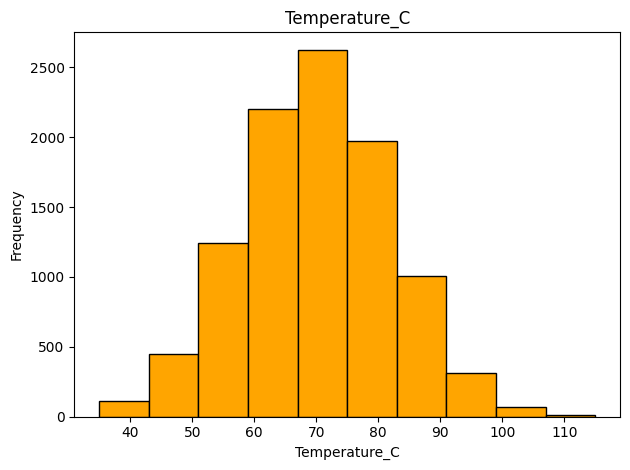

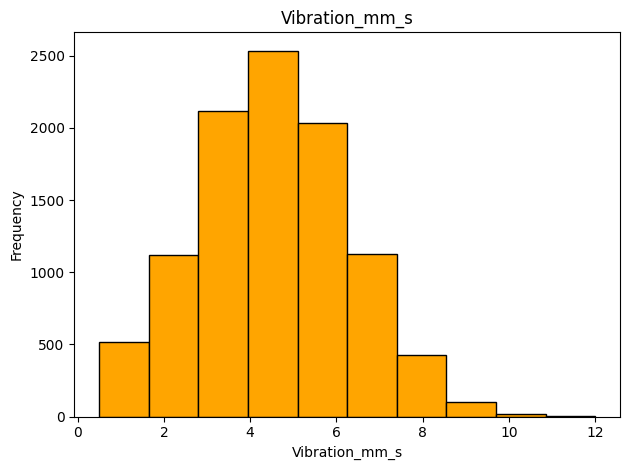

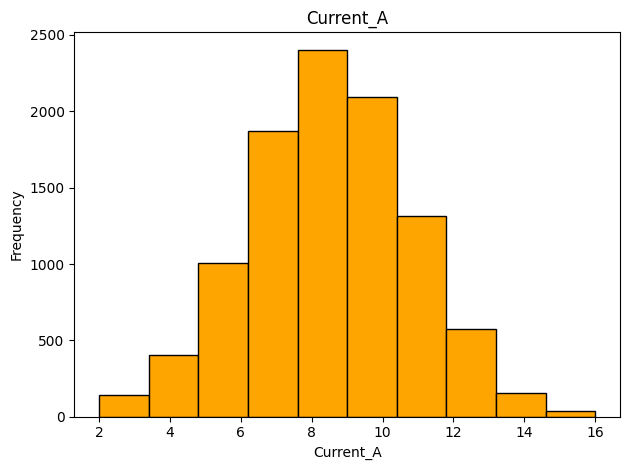

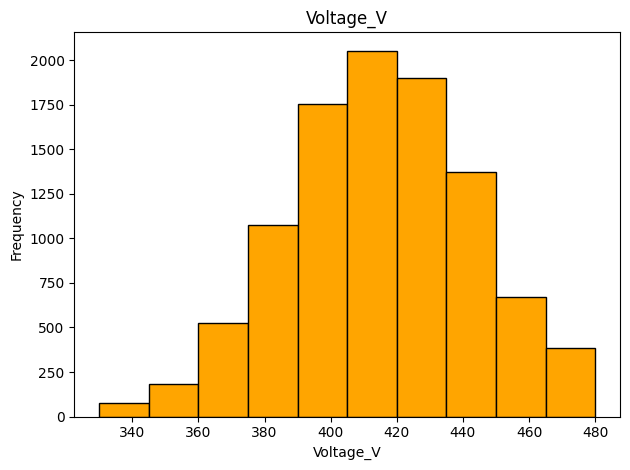

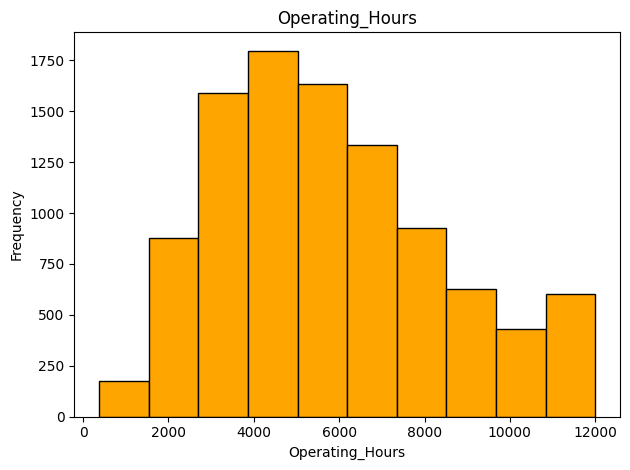

In [ ]:
var = ['Temperature_C','Vibration_mm_s','Current_A','Voltage_V','Operating_Hours']
for i in var:
  plt.hist(df[i],color='orange',edgecolor='black')
  plt.xlabel(i)
  plt.ylabel('Frequency')
  plt.title(i)
  plt.tight_layout()
  plt.show()


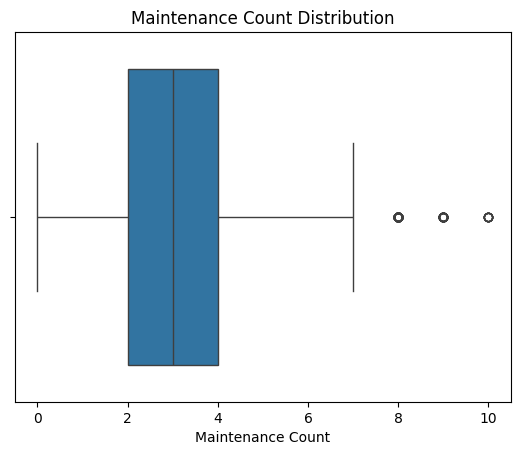

In [ ]:
sns.boxplot(df,x='Maintenance_Count')
plt.xlabel("Maintenance Count")
plt.title("Maintenance Count Distribution")
plt.show()

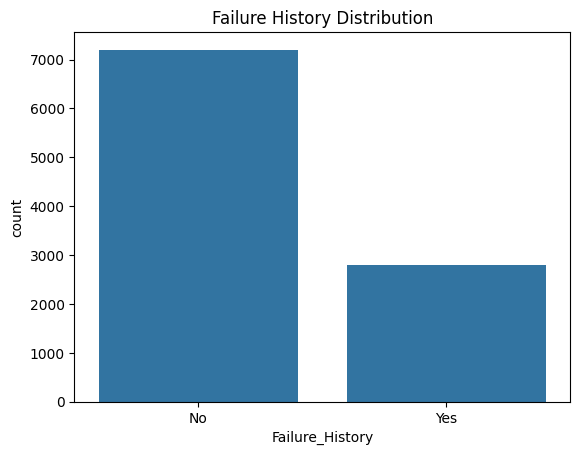

In [ ]:
sns.countplot(x='Failure_History',data=df)
plt.title("Failure History Distribution")
plt.show()

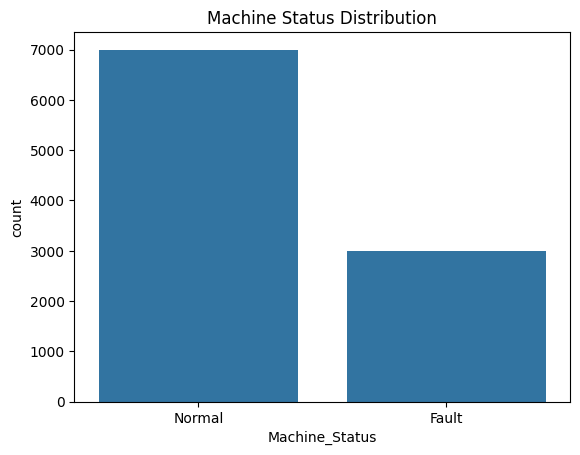

In [ ]:
sns.countplot(x='Machine_Status',data=df)
plt.title("Machine Status Distribution")
plt.show()

# Bivariate Analysis

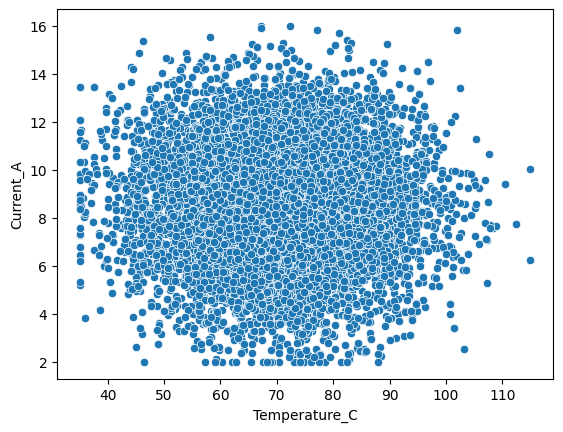

In [ ]:
sns.scatterplot(data=df,
            x="Temperature_C",
            y="Current_A")
plt.show()

In [ ]:
df['Temperature_C'].corr(df['Current_A'])

np.float64(-0.010845977123335253)

In [ ]:
df.columns

Index(['Temperature_C', 'Vibration_mm_s', 'Pressure_bar', 'RPM', 'Current_A',
       'Voltage_V', 'Operating_Hours', 'Load_Percentage', 'Maintenance_Count',
       'Last_Maintenance_Days', 'Failure_History', 'Machine_Status'],
      dtype='object')

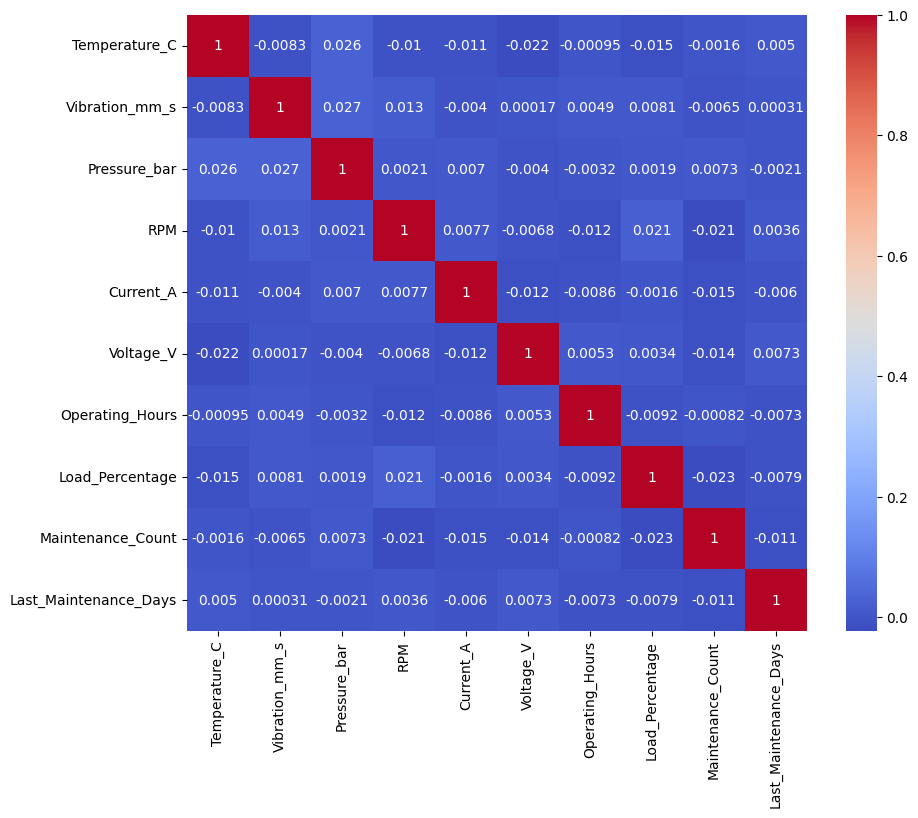

In [ ]:
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

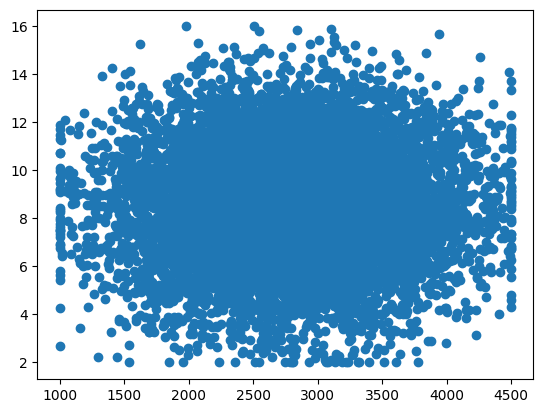

In [ ]:
plt.scatter(df['RPM'],df['Current_A'])
plt.show()

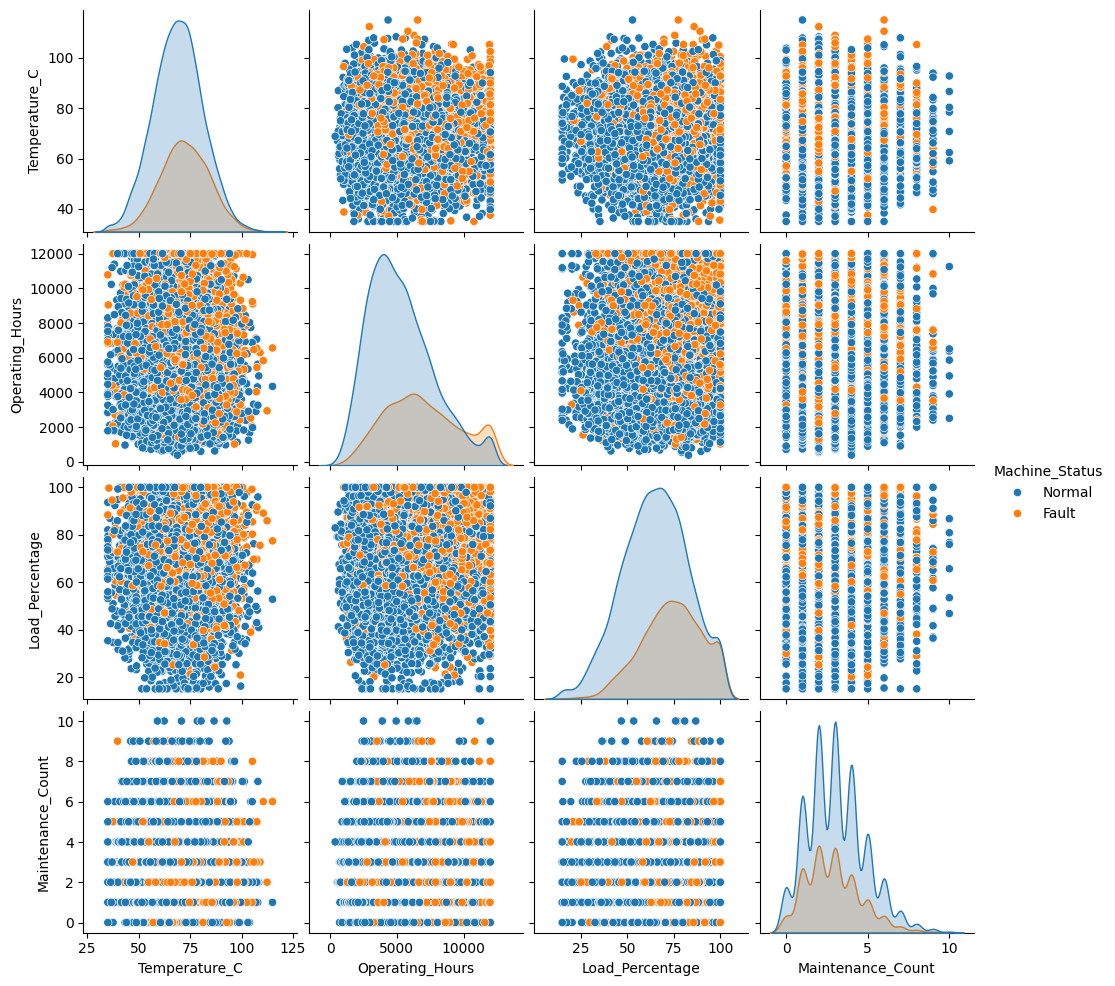

In [ ]:
sns.pairplot(df,vars=['Temperature_C','Operating_Hours','Load_Percentage','Maintenance_Count'],hue='Machine_Status')
plt.show()

# Observation
Vibration, Pressure_bar, Maintenance_count, Load_percentage, RPM, Current_A, Voltage, Operating_hours, and Last_maintenance_days show a positive correlation with the target variable, indicating that these features may have an influence on the target.

# Data Preprocessing

In [ ]:
df['Failure_History'] = df['Failure_History'].map({"Yes":1,
                                                   "No":0})

In [ ]:
df['Machine_Status'] = df['Machine_Status'].map({"Normal":0,
                                                 "Fault":1})

In [ ]:
df.columns

Index(['Temperature_C', 'Vibration_mm_s', 'Pressure_bar', 'RPM', 'Current_A',
       'Voltage_V', 'Operating_Hours', 'Load_Percentage', 'Maintenance_Count',
       'Last_Maintenance_Days', 'Failure_History', 'Machine_Status'],
      dtype='object')

In [ ]:
x = df[['Temperature_C', 'Vibration_mm_s', 'Pressure_bar', 'RPM', 'Current_A',
       'Voltage_V', 'Operating_Hours', 'Load_Percentage', 'Maintenance_Count',
       'Last_Maintenance_Days', 'Failure_History']]
y = df['Machine_Status']

In [ ]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.30,random_state=42,stratify=y)

# LogisticRegression Model

In [ ]:
model_lr = LogisticRegression(max_iter=20000)

In [ ]:
model_lr.fit(x_train,y_train)

LogisticRegression(max_iter=20000)

In [ ]:
y_pred = model_lr.predict(x_test)

In [ ]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[1910,  190],
       [ 279,  621]])

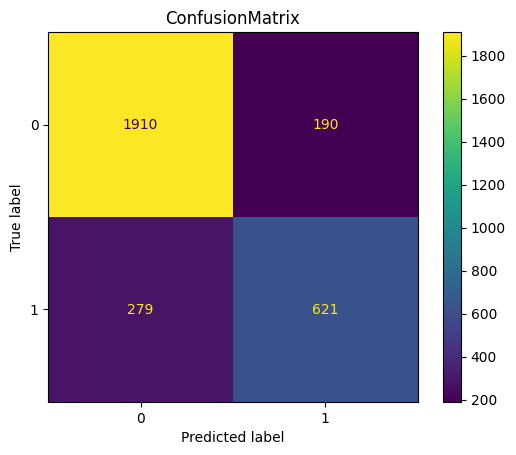

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
plt.title("ConfusionMatrix")
plt.show()

## Model Evaluation

In [ ]:
accuracy_lr = accuracy_score(y_test,y_pred)
precision_lr = precision_score(y_test,y_pred)
recall_lr = recall_score(y_test,y_pred)
f1_lr = f1_score(y_test,y_pred)

y_pred_prob = model_lr.predict_proba(x_test)[:,1]
roc_auc_lr = roc_auc_score(y_test,y_pred_prob)

evaluation_lr = pd.DataFrame({
    "Accuracy":[accuracy_lr],
    "Precision":[precision_lr],
    "Recall":[recall_lr],
    "F1":[f1_lr],
    "Roc_Auc":[roc_auc_lr]
})
evaluation_lr

,Accuracy,Precision,Recall,F1,Roc_Auc
0,0.843667,0.765721,0.69,0.725891,0.918934


# SVM Model

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
model_svm = SVC(kernel='linear',C=10,gamma='scale',probability=True)

In [ ]:
model_svm.fit(x_train_scaled,y_train)

SVC(C=10, kernel='linear', probability=True)

In [ ]:
y_pred = model_svm.predict(x_test_scaled)

In [ ]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[1909,  191],
       [ 278,  622]])

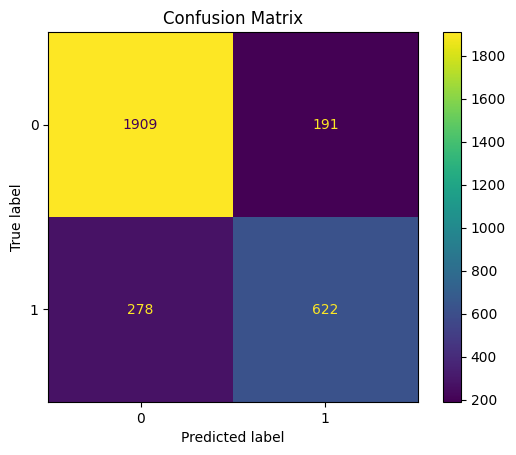

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
plt.title("Confusion Matrix")
plt.show()


## Model Evaluation

In [ ]:
accuracy_sv = accuracy_score(y_test,y_pred)
precision_sv = precision_score(y_test,y_pred)
recall_sv = recall_score(y_test,y_pred)
f1_sv = f1_score(y_test,y_pred)

y_pred_prob = model_svm.predict_proba(x_test_scaled)[:,1]
roc_auc_sv = roc_auc_score(y_test,y_pred_prob)

evaluation_sv = pd.DataFrame({
    "Accuracy":[accuracy_sv],
    "Precision":[precision_sv],
    "Recall":[recall_sv],
    "F1":[f1_sv],
    "Roc_Auc":[roc_auc_sv]
})
evaluation_sv

,Accuracy,Precision,Recall,F1,Roc_Auc
0,0.843667,0.765068,0.691111,0.726211,0.919294


## Fine Tunning

In [ ]:
from sklearn.model_selection import GridSearchCV
params = {
    "kernel":['linear','rbf','poly'],
    "C":[0.1,1,10,100],
    "gamma":['scale','auto']
}

In [ ]:
grid = GridSearchCV(
    SVC(),
    params,
    cv=5
)
grid.fit(x_train_scaled,y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf', 'poly']})

In [ ]:
grid.best_params_

{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}

In [ ]:
grid.best_score_

np.float64(0.8574285714285713)

# Final Model

In [ ]:
best_model = SVC(C=1,gamma="scale",kernel='linear',probability=True)

In [ ]:
best_model.fit(x_train_scaled,y_train)

SVC(C=1, kernel='linear', probability=True)

In [ ]:
y_pred_bs = best_model.predict(x_test_scaled)

In [ ]:
cm = confusion_matrix(y_test,y_pred_bs)
cm

array([[1909,  191],
       [ 280,  620]])

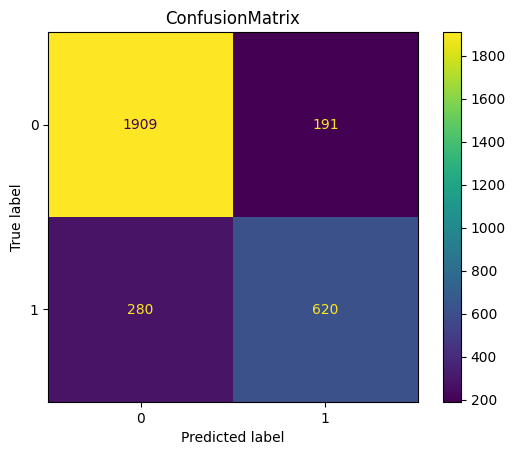

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_bs)
plt.title("ConfusionMatrix")
plt.show()

In [ ]:
accuracy_bs = accuracy_score(y_test,y_pred_bs)
precision_bs = precision_score(y_test,y_pred_bs)
recall_bs = recall_score(y_test,y_pred_bs)
f1_bs = f1_score(y_test,y_pred_bs)

y_pred_prob_bs = best_model.predict_proba(x_test_scaled)[:,1]
roc_auc_bs = roc_auc_score(y_test,y_pred_prob_bs)

evaluation_bs = pd.DataFrame({
    "Accuracy":[accuracy_bs],
    "Precision":[precision_bs],
    "Recall":[recall_bs],
    "F1":[f1_bs],
    "Roc_Auc":[roc_auc_bs]
})
evaluation_bs

,Accuracy,Precision,Recall,F1,Roc_Auc
0,0.843,0.764488,0.688889,0.724722,0.919268


## Model Evaluation

In [ ]:
comparision = pd.DataFrame({
    "Model":["LogisticRegression",'SVC','SVC(Fine Tuned)'],
    "Accuracy":[accuracy_lr,accuracy_sv,accuracy_bs],
    "Precision":[precision_lr,precision_sv,precision_bs],
    "Recall":[recall_lr,recall_sv,recall_bs],
    "F1":[f1_lr,f1_sv,f1_bs],
    "ROX_AUC":[roc_auc_lr,roc_auc_sv,roc_auc_bs]
})
comparision

,Model,Accuracy,Precision,Recall,F1,ROX_AUC
0,LogisticRegression,0.843667,0.765721,0.690000,0.725891,0.918934
1,SVC,0.843667,0.765068,0.691111,0.726211,0.919294
2,SVC(Fine Tuned),0.843000,0.764488,0.688889,0.724722,0.919268


# Conclusion
The models were evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC. Logistic Regression was used as the baseline model, followed by SVC and a fine-tuned SVC model. The standard SVC achieved the best overall performance, with an F1-score of 72.62% and ROC-AUC of 91.93%. Fine-tuning did not improve the results and produced slightly lower performance. Therefore, SVC was selected as the final model for the Machine Fault Detection project.